In [1]:
import qiskit
import qc_grader
print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.1.1
Grader version: 0.22.12


In [ ]:
# Check that the account has been saved properly
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()

In [4]:
# Import common packages first
import numpy as np
from math import comb
import warnings
import pyscf
import matplotlib.pyplot as plt
import pickle
from functools import partial

# Import qiskit classes
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_gate_map
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch

# Import qiskit ecosystems
import ffsim
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime import SamplerOptions

# Import grader
from qc_grader.challenges.qgss_2025 import (
    grade_lab3_ex1, 
    grade_lab3_ex2, 
    grade_lab3_ex3,
    grade_lab3_ex4,
    grade_lab3_ex5
)

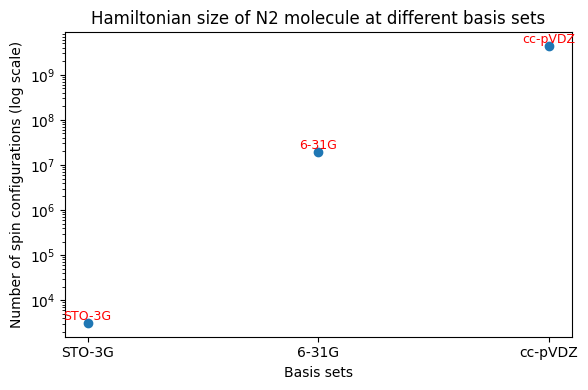

In [5]:
# Number of possible spin configurations
# Example: N2 molecule in STO-3G, 6-31G, and cc-pVDZ basis sets
# 14 electrons, 20 spin orbitals (from 10 spatial orbitals × 2)

# Calculate total electron configurations for each basis set
y1 = comb(8, 5) * comb(8, 5)       # STO-3G
y2 = comb(16, 5) * comb(16, 5)     # 6-31G
y3 = comb(26, 5) * comb(26, 5)     # cc-pVDZ

# Data
y = [y1, y2, y3]
x = list(range(len(y)))
labels = ['STO-3G', '6-31G', 'cc-pVDZ']

# Plot with logarithmic y-scale
plt.figure(figsize=(6, 4))
plt.plot(x, y, 'o')

plt.yscale('log')
plt.xticks(x, labels)
plt.xlabel('Basis sets')
plt.ylabel('Number of spin configurations (log scale)')
plt.title('Hamiltonian size of N2 molecule at different basis sets')

# Add labels above points
for i in range(len(x)):
    plt.text(x[i], y[i], f'{labels[i]}', fontsize=9, ha='center', va='bottom', color='red')

plt.tight_layout()
plt.show()

In [6]:
from math import comb

α_config = comb(16, 7)
β_config = comb(16, 5)
total_config = α_config * β_config

print(f"Total physical configurations for O2 in the given basis : {α_config:} x {β_config:} = {total_config}")


grade_lab3_ex1(total_config)


Total physical configurations for O2 in the given basis : 11440 x 4368 = 49969920
Submitting your answer. Please wait...
Congratulations 🎉! Your answer is correct and has been submitted.


In [7]:
service = QiskitRuntimeService(name="qgss-2025")
backend = service.backend("ibm_brisbane")

In [8]:
n = [0.007, 0.029, 0.029, 0.995, 
     0.976, 0.976, 0.993, 0.997, 
     0.007, 0.029, 0.029, 0.995,
     0.976, 0.976, 0.993, 0.997]

x = [1, 0, 0, 0,  1, 0, 1, 1,  1, 0, 1, 1,  1, 1, 0, 0]

In [9]:
x = np.array(x)
n = np.array(n)

# ---- TODO : Task 2 ---
# ---- TODO : Task 2 ---

# Divide into alpha spin and beta spin
x_alpha = x[8:]
x_beta = x[:8]
n_alpha = n[8:]
n_beta = n[:8]

h = 5/8    
delta = 0.01

# probability of flipping (ReLU)
y_beta = np.zeros_like(x_beta, dtype=float)
for i in range(len(x_beta)):
    if x_beta[i] == 1:
        y_beta[i] = 0.0
    else:
        y_beta[i] = max(0.0, n_beta[i] - h + delta)

max_index = np.argmax(y_beta)

x_new = x.copy()
x_new[max_index] = 1


corrected_x = x_new.tolist()

# --- End of TODO ---

print("y_beta =", y_beta)
print("max_index =", max_index)
print("corrected_x =", corrected_x)

y_beta = [0.    0.    0.    0.38  0.    0.361 0.    0.   ]
max_index = 3
corrected_x = [1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0]


In [10]:
grade_lab3_ex2(corrected_x)

Submitting your answer. Please wait...
Congratulations 🎉! Your answer is correct and has been submitted.


In [11]:
warnings.filterwarnings("ignore")

# Specify molecule properties
open_shell = False
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=[["N", (0, 0, 0)], ["N", (1.0, 0, 0)]],
    # ---- TODO : Task 3 ---
    basis='cc-pvdz',

    # --- End of TODO ---
    symmetry="Dooh"
)


# Define active space
n_frozen = 2
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
num_orbitals = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons - mol.spin) // 2
cas = pyscf.mcscf.CASCI(scf, num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

print(num_orbitals)

converged SCF energy = -108.929838385609
26


In [12]:
num_orbitals = len(active_space)
n_qubits = 2 * num_orbitals + 6 

print("num_orbitals =", num_orbitals)
print("n_qubits =", n_qubits)


num_orbitals = 26
n_qubits = 58


In [13]:
grade_lab3_ex3(n_qubits)

Submitting your answer. Please wait...
Congratulations 🎉! Your answer is correct and has been submitted.


In [14]:
# from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(name="qgss-2025")
# backend = service.backend('ibm_torino') 
# backend_target = backend.target

In [15]:
backend = service.backend('ibm_torino') 

In [16]:
import qiskit
print(f'Qiskit: {qiskit.__version__}')

Qiskit: 2.1.1


In [17]:
# select the initial layout
import pickle

# for Qiskit version 2.1.x users
with open("utils/backend_target_v21.pkl", "rb") as f:
    backend_target = pickle.load(f)

BAD_READOUT_ERROR_THRESHOLD = 0.1
BAD_CZGATE_ERROR_THRESHOLD = 0.1
backend_num_qubits = 133


bad_readout_qubits = [
    i for i in range(backend_num_qubits) 
    if backend_target["measure"][(i,)].error > BAD_READOUT_ERROR_THRESHOLD
]

bad_czgate_edges = [
    edge for edge in backend_target.build_coupling_map().get_edges()
    if backend_target["cz"][edge].error > BAD_CZGATE_ERROR_THRESHOLD
]

print("Bad readout qubits:", bad_readout_qubits)
print("Bad CZ gates:", bad_czgate_edges)


#spin_a_layout = [1,2,3,4,16,23,24,25,35,44,45,55,65,66,67,74,86,87,88,94,107,108,109,113]
#spin_b_layout = [15,19,20,21,34,40,41,42,54,61,62,63,73,82,83,84,93,103,104,105,112,124] 

spin_a_layout = [2,3,4,16,23,24,25,35,44,45,46,55,65,66,67,74,86,87,88,94,107,108,109,113,128,127]
spin_b_layout = [0,15,19,20,21,34,40,41,42,54,61,62,63,73,82,83,84,93,103,104,105,112,124,123,122,121]

initial_layout = spin_a_layout + spin_b_layout
print(initial_layout)

Bad readout qubits: [12, 53, 115, 126, 131]
Bad CZ gates: [(100, 101), (101, 100)]
[2, 3, 4, 16, 23, 24, 25, 35, 44, 45, 46, 55, 65, 66, 67, 74, 86, 87, 88, 94, 107, 108, 109, 113, 128, 127, 0, 15, 19, 20, 21, 34, 40, 41, 42, 54, 61, 62, 63, 73, 82, 83, 84, 93, 103, 104, 105, 112, 124, 123, 122, 121]


In [18]:
# Submit your answer using following code

grade_lab3_ex4(initial_layout) # Expected result type: lists

Submitting your answer. Please wait...
Congratulations 🎉! Your answer is correct and has been submitted.


In [19]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]).run()
t1 = ccsd.t1
t2 = ccsd.t2

n_reps = 1
# ---- TODO : Task 5 ---
alpha_alpha_indices = []
for p in range(num_orbitals-2):
    alpha_alpha_indices.append((p,p+1))
alpha_alpha_indices.append((num_orbitals-2,num_orbitals-1))
for p in range(num_orbitals-2):
    alpha_alpha_indices.append((p,p+2))
alpha_alpha_indices = sorted(list(set(alpha_alpha_indices)))
# --- End of TODO ---
alpha_beta_indices = [(p, p) for p in range(0, num_orbitals, 4)]

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)
print(alpha_alpha_indices)
nelec = (num_elec_a, num_elec_b)

# create an empty quantum circuit
qubits = QuantumRegister(2 * num_orbitals, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()
circuit.decompose().decompose().draw("mpl", fold=-1)

E(CCSD) = -109.2177884185543  E_corr = -0.2879500329450039
[(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (4, 5), (4, 6), (5, 6), (5, 7), (6, 7), (6, 8), (7, 8), (7, 9), (8, 9), (8, 10), (9, 10), (9, 11), (10, 11), (10, 12), (11, 12), (11, 13), (12, 13), (12, 14), (13, 14), (13, 15), (14, 15), (14, 16), (15, 16), (15, 17), (16, 17), (16, 18), (17, 18), (17, 19), (18, 19), (18, 20), (19, 20), (19, 21), (20, 21), (20, 22), (21, 22), (21, 23), (22, 23), (22, 24), (23, 24), (23, 25), (24, 25)]


In [ ]:
grade_lab3_ex5(alpha_alpha_indices)

In [21]:
# Check your submission status with the code below
from qc_grader.grader.grade import check_lab_completion_status

check_lab_completion_status("qgss_2025")

Lab 0: 2/2 exercises completed (100%)
    ✅ 2153 participants have completed this lab
Lab 1: 9/9 exercises completed (100%)
    ✅ 1548 participants have completed this lab
Lab 2: 7/7 exercises completed (100%)
    ✅ 810 participants have completed this lab
Lab 3: 5/5 exercises completed (100%)
    ✅ 534 participants have completed this lab
Lab 4: 6/6 exercises completed (100%)
    ✅ 273 participants have completed this lab
Functions Labs: 0/8 exercises completed (0%)
    ✅ 2 participants have completed this lab
